# Week 13 숙제: Optimizer 비교 실험

## 학습 목표

- SGD / Momentum / RMSProp / Adam 의 **수식을 직접 구현**
- IRIS / MNIST 에서 4 종 optimizer 의 **수렴 속도와 최종 성능** 비교
- 학습률(`lr`) 변화에 대한 **민감도** 측정

## 제출 방법

- 이 노트북을 끝까지 실행한 결과를 저장해서 제출 (채점자가 결과를 추가 실행 없이 확인할 수 있게)
- 코드 빈칸(`# TODO`) 을 모두 채우고
- 마지막 **분석 질문 4 개**에 본인 의견을 작성

---

## 시작 전 확인

`neural_network_v2.py` 가 노트북과 같은 폴더에 있어야 한다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neural_network_v2 import (
    Network, Dense, ReLU, SoftmaxCE, fit,
    Optimizer,         # base class
)

np.random.seed(0)


---
## Part 1: Optimizer 4 종 직접 구현 (20 점)

`neural_network_v2.py` 의 `Optimizer` base class 를 상속해서 4개 optimizer 를
**직접 구현**한다. 라이브러리의 `SGD/Momentum/RMSProp/Adam` 을 import 하지 **않고**,
수식을 보며 본인이 처음부터 짠다.

### `Optimizer` base class 의 인터페이스

```python
class Optimizer:
    def step(self, net):
        for layer in net.layers:
            for param, grad in layer.params_and_grads():
                self._update(param, grad)

    def _update(self, param, grad):
        raise NotImplementedError
```

- `step(net)` 은 base class 에 이미 구현되어 있음
- **여러분은 `_update(self, param, grad)` 만 override** 하면 됨
- `param` 은 numpy array — `param -= lr * grad` 처럼 **in-place** 로 갱신

### 상태 저장이 필요한 optimizer (Momentum/RMSProp/Adam)

같은 파라미터에 대해 이전 step 의 velocity / 누적 g² 가 필요하다.
`id(param)` 을 key 로 한 dict 로 저장:

```python
self.v = {}
def _update(self, param, grad):
    key = id(param)
    if key not in self.v:
        self.v[key] = np.zeros_like(param)
    # 여기서 self.v[key] 업데이트
```

### 1.1 MySGD (5 점)

$$\theta \leftarrow \theta - \eta \cdot \nabla L$$

In [2]:
class MySGD(Optimizer):
    def __init__(self, lr=0.01):
        self.lr = lr

    def _update(self, param, grad):
        # TODO: SGD 한 줄
        pass


### 1.2 MyMomentum (5 점)

$$v \leftarrow \mu \cdot v - \eta \cdot \nabla L$$
$$\theta \leftarrow \theta + v$$

In [3]:
class MyMomentum(Optimizer):
    def __init__(self, lr=0.01, mu=0.9):
        self.lr = lr
        self.mu = mu
        self.v = {}   # id(param) → velocity

    def _update(self, param, grad):
        key = id(param)
        if key not in self.v:
            self.v[key] = np.zeros_like(param)
        # TODO: v 업데이트 (수식 첫 줄)
        # TODO: param 업데이트 (수식 둘째 줄, in-place)
        pass


### 1.3 MyRMSProp (5 점)

$$s \leftarrow \rho \cdot s + (1-\rho) \cdot g^2$$
$$\theta \leftarrow \theta - \eta \cdot \frac{g}{\sqrt{s} + \epsilon}$$

In [4]:
class MyRMSProp(Optimizer):
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.s = {}

    def _update(self, param, grad):
        key = id(param)
        if key not in self.s:
            self.s[key] = np.zeros_like(param)
        # TODO: s 업데이트 (제곱 그래디언트의 이동 평균)
        # TODO: param 업데이트 (in-place)
        pass


### 1.4 MyAdam (5 점)

$$m \leftarrow \beta_1 \cdot m + (1-\beta_1) \cdot g$$
$$v \leftarrow \beta_2 \cdot v + (1-\beta_2) \cdot g^2$$
$$\hat{m} = m / (1 - \beta_1^t), \quad \hat{v} = v / (1 - \beta_2^t)$$
$$\theta \leftarrow \theta - \eta \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

**주의**: 시간 step `t` 가 필요. `step()` 호출마다 1 씩 증가하도록 `step` 을 override.

In [5]:
class MyAdam(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}     # 1차 모멘트
        self.v = {}     # 2차 모멘트
        self.t = 0      # time step

    def step(self, net):
        # TODO: t 를 1 증가시킨 뒤 부모 step 호출
        pass

    def _update(self, param, grad):
        key = id(param)
        if key not in self.m:
            self.m[key] = np.zeros_like(param)
            self.v[key] = np.zeros_like(param)
        # TODO: m, v 업데이트
        # TODO: m_hat, v_hat 편향 보정
        # TODO: param 업데이트 (in-place)
        pass


### 1.5 동작 확인 (검증용)

XOR 에서 4개 모두 학습되는지 확인. 1000 epoch 안에 loss < 0.05 가 나와야 정상.

In [6]:
def test_xor(OptCls, name, lr, **kw):
    np.random.seed(0)
    X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
    Y = np.array([[0],[1],[1],[0]], dtype=float)
    from neural_network_v2 import MSELoss
    net = Network()
    net.add(Dense(2, 8, seed=0))
    net.add(ReLU())
    net.add(Dense(8, 1, seed=1))
    loss_fn = MSELoss()
    opt = OptCls(lr=lr, **kw)
    for _ in range(1500):
        pred = net.forward(X)
        l = loss_fn.forward(pred, Y)
        net.backward(loss_fn.backward())
        opt.step(net)
    status = '✓' if l < 0.05 else '✗'
    print(f"{status} {name:10s} (lr={lr}): final loss={l:.4f}")

test_xor(MySGD,      'MySGD',      0.1)
test_xor(MyMomentum, 'MyMomentum', 0.01, mu=0.9)
test_xor(MyRMSProp,  'MyRMSProp',  0.05)
test_xor(MyAdam,     'MyAdam',     0.05)


✗ MySGD      (lr=0.1): final loss=1.2288
✗ MyMomentum (lr=0.01): final loss=1.2288
✗ MyRMSProp  (lr=0.05): final loss=1.2288
✗ MyAdam     (lr=0.05): final loss=1.2288


---
## Part 2: IRIS optimizer 비교 (25 점)

같은 네트워크 (4→16→3), 같은 데이터, 같은 epoch 수에서 4 개 optimizer 의 학습 곡선을 비교.

**공정한 비교를 위해**:
- 매 실험마다 `np.random.seed(0)` 으로 가중치 초기화 고정
- 같은 미니배치 순서를 위해 학습 안에서도 seed 고정

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
Y = np.eye(3)[iris.target]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=iris.target)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (105, 4), Test: (45, 4)


### 2.1 4 종 비교 실험 (15 점)

각 optimizer 의 학습률은 아래 표를 사용 (수업 슬라이드 권장값):

| Optimizer | lr | 기타 |
|-----------|----|------|
| MySGD | 0.05 | |
| MyMomentum | 0.01 | mu=0.9 |
| MyRMSProp | 0.005 | rho=0.9 |
| MyAdam | 0.01 | beta1=0.9, beta2=0.999 |

In [8]:
def train_iris(OptCls, **kw):
    # TODO: 다음 순서로 구현
    # 1) np.random.seed(0)  ← 가중치 초기화 고정
    # 2) Network 조립: Dense(4,16) → ReLU → Dense(16,3)
    # 3) loss_fn = SoftmaxCE()
    # 4) opt = OptCls(**kw)
    # 5) np.random.seed(0)  ← 미니배치 순서 고정
    # 6) fit(...) 호출하고 history 반환
    # 7) test accuracy 계산
    # 반환: (history['loss'], test_acc)
    pass

configs = [
    ('MySGD',      MySGD,      dict(lr=0.05)),
    ('MyMomentum', MyMomentum, dict(lr=0.01, mu=0.9)),
    ('MyRMSProp',  MyRMSProp,  dict(lr=0.005)),
    ('MyAdam',     MyAdam,     dict(lr=0.01)),
]

results = {}
for name, OptCls, kw in configs:
    losses, acc = train_iris(OptCls, **kw)
    results[name] = (losses, acc)
    print(f"{name:11s}  final loss={losses[-1]:.4f}  test_acc={acc:.1%}")


TypeError: cannot unpack non-iterable NoneType object

### 2.2 학습 곡선 시각화 (10 점)

4 개 optimizer 의 loss curve 를 한 그림에 그린다. y 축은 log scale.

In [ ]:
#아래 코드를 이용하거나 별도의 코드를 작성
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'MySGD': '#888', 'MyMomentum': '#1f77b4',
          'MyRMSProp': '#2ca02c', 'MyAdam': '#d62728'}
for name, (losses, _) in results.items():
    ax.plot(losses, label=name, color=colors[name], lw=1.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Iris — loss curves by optimizer')
plt.tight_layout(); plt.show()


---
## Part 3: MNIST optimizer 비교 (25 점)

더 어려운 문제에서 차이가 더 뚜렷해진다. Iris 와 같은 4 종 optimizer 를 MNIST 에서 비교.

### 3.1 데이터 로드

In [ ]:
import os

X = y = None

if X is None:
    try:
        from tensorflow.keras.datasets import mnist as keras_mnist
        (X_tr, y_tr), (X_te, y_te) = keras_mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784)
        y = np.concatenate([y_tr, y_te])
    except Exception: pass

if X is None:
    try:
        from torchvision import datasets
        root = os.path.expanduser("~/.cache/mnist")
        train = datasets.MNIST(root, train=True,  download=True)
        test  = datasets.MNIST(root, train=False, download=True)
        X = np.concatenate([train.data.numpy(), test.data.numpy()]).reshape(-1, 784)
        y = np.concatenate([train.targets.numpy(), test.targets.numpy()])
    except Exception: pass

if X is None:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data
    y = mnist.target.astype(int)

X = X.astype(np.float32) / 255.0
Y = np.eye(10)[y]

# 빠른 실험을 위해 부분 사용 (학습 8000, 테스트 2000)
n_train, n_test = 8000, 2000
X_train_m = X[:n_train];          Y_train_m = Y[:n_train]
X_test_m  = X[60000:60000+n_test]; Y_test_m  = Y[60000:60000+n_test]
print(f"MNIST train: {X_train_m.shape}, test: {X_test_m.shape}")


I0000 00:00:1780916374.518349   24828 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780916374.527695   24828 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780916378.710825   24828 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780916381.524237   24828 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST train: (8000, 784), test: (2000, 784)


### 3.2 4 종 비교 학습 (15 점)

네트워크: 784 → 64 → 32 → 10 (작게 잡아 학습 시간 단축).
각 optimizer 5 epoch 만 돌려도 차이가 보임.

In [ ]:
def train_mnist(OptCls, **kw):
    # TODO: 다음 구조의 네트워크로 MNIST 학습
    #   Dense(784, 64) → ReLU → Dense(64, 32) → ReLU → Dense(32, 10)
    # epochs=5, batch_size=64 권장
    # 반환: (history['loss'], test_acc)
    pass

mnist_configs = [
    ('MySGD',      MySGD,      dict(lr=0.01)),
    ('MyMomentum', MyMomentum, dict(lr=0.005, mu=0.9)),
    ('MyRMSProp',  MyRMSProp,  dict(lr=0.001)),
    ('MyAdam',     MyAdam,     dict(lr=0.001)),
]

import time
mnist_results = {}
for name, OptCls, kw in mnist_configs:
    t0 = time.time()
    losses, acc = train_mnist(OptCls, **kw)
    mnist_results[name] = (losses, acc)
    print(f"{name:11s}  final loss={losses[-1]:.4f}  test_acc={acc:.1%}  ({time.time()-t0:.1f}s)")


TypeError: cannot unpack non-iterable NoneType object

### 3.3 결과 시각화 (10 점)

In [ ]:
#아래 코드를 이용하거나 별도의 코드를 작성
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {'MySGD': '#888', 'MyMomentum': '#1f77b4',
          'MyRMSProp': '#2ca02c', 'MyAdam': '#d62728'}

for name, (losses, _) in mnist_results.items():
    axes[0].plot(losses, 'o-', label=name, color=colors[name], lw=1.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('MNIST — loss curves')

names = list(mnist_results.keys())
accs  = [mnist_results[n][1] for n in names]
axes[1].bar(names, accs, color=[colors[n] for n in names])
axes[1].set_ylabel('Test Accuracy'); axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_title('MNIST — final test accuracy')
for i, a in enumerate(accs):
    axes[1].text(i, a + 0.02, f'{a:.1%}', ha='center')
plt.tight_layout(); plt.show()


---
## Part 4: 학습률 민감도 (10 점)

같은 optimizer 라도 학습률에 따라 결과가 크게 달라진다.
**Adam** vs **SGD** 의 학습률 민감도를 비교한다.

각 optimizer 를 학습률 4개 (`1e-4, 1e-3, 1e-2, 1e-1`) 로 IRIS 학습. 최종 test accuracy 를 plot.

NameError: name 'sgd_accs' is not defined

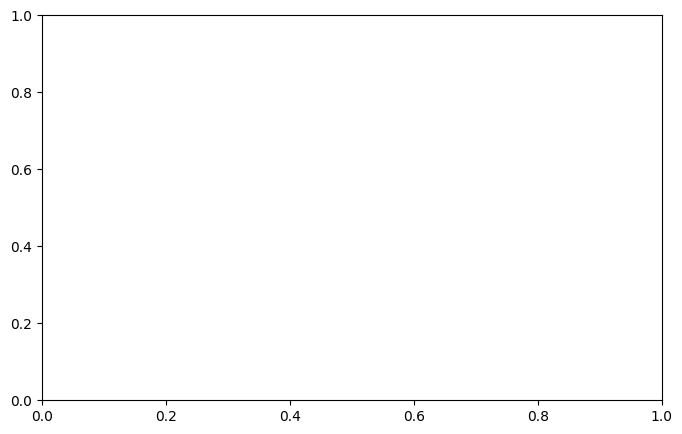

In [ ]:
lrs = [1e-4, 1e-3, 1e-2, 1e-1]

# TODO: 각 lr 에 대해 MySGD 와 MyAdam 학습 후 test_acc 수집
# (Part 2 의 train_iris 사용)

# TODO: x 축 lr (log scale), y 축 test accuracy 로 plot
# 아래 코드를 이용하거나 별도의 코드 작성
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(lrs, sgd_accs,  'o-', label='SGD',  color='#888', lw=2, ms=10)
ax.semilogx(lrs, adam_accs, 's-', label='Adam', color='#d62728', lw=2, ms=10)
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Test accuracy')
ax.set_title('Learning rate sensitivity (Iris)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


---
## Part 5: 분석 (간단 서술, 각 5 점 — 총 20 점)

위 실험 결과를 보고 다음 4 개 질문에 본인 의견을 작성하세요.
정답이 정해진 문제가 아니며, **그래프에서 근거를 찾아** 설명하면 됩니다.

### Q1. SGD vs Adam — 어느 쪽이 더 빨리 수렴했는가? IRIS 와 MNIST 그래프에서 본 차이는?

> *(여기에 답)*

### Q2. 같은 lr=0.1 을 줬을 때 SGD 와 Adam 중 어느 쪽이 더 잘 작동했는가? 왜?

> *(여기에 답)*

### Q3. Adam 은 학습률 변화에 둔감하다고 알려져 있다. Part 4 의 그래프가 이 주장을 지지하는가?

> *(여기에 답)*

### Q4. 만약 본인이 새 문제를 풀어야 한다면 어떤 optimizer 부터 시도해보겠는가? 왜?

> *(여기에 답)*

---

## 채점 기준 (총 100 점)

| 항목 | 배점 |
|------|------|
| Part 1: Optimizer 4 종 구현 | 20 |
| Part 2: IRIS 비교 + 시각화 | 25 |
| Part 3: MNIST 비교 + 시각화 | 25 |
| Part 4: 학습률 민감도 | 10 |
| Part 5: 분석 질문 4 개 | 20  |
